## Postprocessing and Analysis of Monte Carlo Results

In this notebook, we analyze the Monte Carlo simulation results obtained from the three reconstruction strategies:

* DG-based SIAC filtering applied post-FBP  (`dg`)
* Fourier-domain SIAC filtering applied post-FBP (`fourier`)
* Detector-domain SIAC filtering applied pre-FBP (`detector`)

The raw simulation outputs have been precomputed and stored as CSV files. Each row corresponds to a single Monte Carlo realization for a given noise level and parameter configuration, including:

* reconstruction parameters (e.g. polynomial degree (p), number of moments, B-spline order),
* noise level and random seed,
* quantitative evaluation metrics:

  * relative ($L^2$) error,
  * masked relative ($L^2$) error,
  * gradient-weighted SSIM,
  * SSIM.

The purpose of this notebook is to:

1. Load and unify the results from all methods into a single dataset.
2. Compute summary statistics (mean, standard deviation, etc.) over Monte Carlo repetitions.
3. Identify optimal parameter configurations for each method as a function of noise level.
4. Compare reconstruction performance across methods using multiple metrics.
5. Visualize trends, parameter sensitivity, and robustness.

This separation between simulation and analysis ensures reproducibility, simplifies experimentation, and enables flexible exploration of the results without rerunning computationally expensive simulations.


In [1]:
import numpy as np
import pandas as pd

import sys
sys.path.append("../..")

from src.metrics import(
    summarize_mc_results, 
    select_best_by_noise, 
    select_fixed_params_from_reference_noise, 
    filter_summary_by_fixed_params
)
from src.plotting_helpers import (
    display_best_params, 
    plot_mc_metric, 
    plot_selected_param_vs_noise, 
    plot_param_heatmap, 
    compare_fixed_vs_retuned
)

In [2]:
# Read result files
results_dg = pd.read_csv("results_dg.csv")
results_fourier = pd.read_csv("results_fourier.csv")
results_detector = pd.read_csv("results_detector.csv")

# Ensure all dataframes share the same columns
if "p" not in results_fourier.columns:
    results_fourier["p"] = np.nan

if "p" not in results_detector.columns:
    results_detector["p"] = np.nan

common_cols = [
    "method", "noise_level", "rep", "seed",
    "p", "moments", "BSorder",
    "rel_l2_err", "masked_rel_l2_err", "gw_ssim", "ssim"
]

results_dg = results_dg[common_cols]
results_fourier = results_fourier[common_cols]
results_detector = results_detector[common_cols]

# Combine into one dataframe
results_all = pd.concat(
    [results_dg, results_fourier, results_detector],
    ignore_index=True
)

# Quick sanity checks
print("Shape of combined dataframe:", results_all.shape)
print("\nMethods:")
print(results_all["method"].value_counts())

print("\nMissing values:")
print(results_all.isna().sum())

Shape of combined dataframe: (18200, 11)

Methods:
method
detector    10920
dg           4480
fourier      2800
Name: count, dtype: int64

Missing values:
method                   0
noise_level              0
rep                      0
seed                     0
p                    13720
moments                  0
BSorder                  0
rel_l2_err               0
masked_rel_l2_err        0
gw_ssim                  0
ssim                     0
dtype: int64


In [3]:
summary_all = summarize_mc_results(
    results_all,
    metric_cols=["rel_l2_err", "masked_rel_l2_err", "gw_ssim", "ssim"]
)

summary_all.head(5)

,method,noise_level,p,moments,BSorder,rel_l2_err_mean,rel_l2_err_std,rel_l2_err_min,rel_l2_err_max,masked_rel_l2_err_mean,...,masked_rel_l2_err_min,masked_rel_l2_err_max,gw_ssim_mean,gw_ssim_std,gw_ssim_min,gw_ssim_max,ssim_mean,ssim_std,ssim_min,ssim_max
0,detector,0.01,NaN,2,8,0.276196,0.000256,0.275646,0.276661,0.261107,...,0.260246,0.261721,0.911436,0.000261,0.911022,0.912104,0.690248,0.000942,0.688594,0.691502
1,detector,0.01,NaN,2,9,0.282462,0.000244,0.281945,0.282908,0.269315,...,0.268531,0.269857,0.905940,0.000251,0.905526,0.906574,0.701291,0.000932,0.699617,0.702682
2,detector,0.01,NaN,2,10,0.288563,0.000232,0.288075,0.288992,0.277049,...,0.276333,0.277530,0.900507,0.000242,0.900094,0.901110,0.711337,0.000923,0.709670,0.712835
3,detector,0.01,NaN,2,11,0.294473,0.000221,0.294012,0.294885,0.284339,...,0.283681,0.284766,0.895156,0.000233,0.894744,0.895731,0.720465,0.000912,0.718828,0.722043
4,detector,0.01,NaN,2,12,0.300180,0.000212,0.299744,0.300578,0.291219,...,0.290612,0.291606,0.889895,0.000226,0.889485,0.890444,0.728743,0.000901,0.727154,0.730380


,method,noise_level,p,moments,BSorder,rel_l2_err_mean,rel_l2_err_std
0,detector,0.01,NaN,6,8,0.251010,0.000280
1,detector,0.02,NaN,6,8,0.259680,0.000542
2,detector,0.03,NaN,6,8,0.273507,0.000794
3,detector,0.04,NaN,4,8,0.291216,0.001018
4,detector,0.05,NaN,4,9,0.308657,0.001219
5,detector,0.06,NaN,2,8,0.325284,0.001407
6,detector,0.07,NaN,2,10,0.340616,0.001500
7,detector,0.08,NaN,2,11,0.354671,0.001636
8,detector,0.09,NaN,2,13,0.367657,0.001698
9,detector,0.10,NaN,2,15,0.379682,0.001750


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best relative $L^2$ error vs noise level'}, xlabel='Noise level', ylabel='Relative $L^2$ error'>)

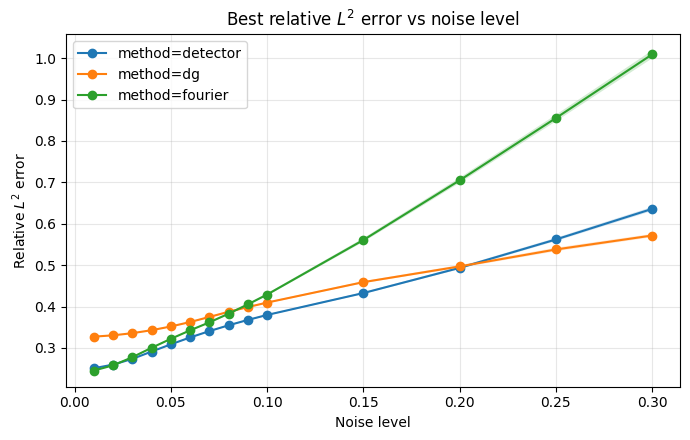

In [4]:
best_rel_l2 = select_best_by_noise(
    summary_all,
    metric="rel_l2_err",
    minimize=True,
)

display_best_params(best_rel_l2, metric="rel_l2_err")

plot_mc_metric(
    best_rel_l2,
    metric="rel_l2_err",
    title="Best relative $L^2$ error vs noise level",
    ylabel="Relative $L^2$ error",
    style_cols=[],
)

,method,noise_level,p,moments,BSorder,masked_rel_l2_err_mean,masked_rel_l2_err_std
0,detector,0.01,NaN,6,8,0.221107,0.000504
1,detector,0.02,NaN,6,8,0.226377,0.001006
2,detector,0.03,NaN,6,8,0.234892,0.001491
3,detector,0.04,NaN,6,8,0.246314,0.001950
4,detector,0.05,NaN,6,8,0.260261,0.002378
5,detector,0.06,NaN,6,8,0.276352,0.002775
6,detector,0.07,NaN,6,10,0.292935,0.002877
7,detector,0.08,NaN,4,10,0.308122,0.002808
8,detector,0.09,NaN,4,11,0.322097,0.002927
9,detector,0.10,NaN,4,13,0.335035,0.002878


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best masked relative $L^2$ error vs noise level'}, xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

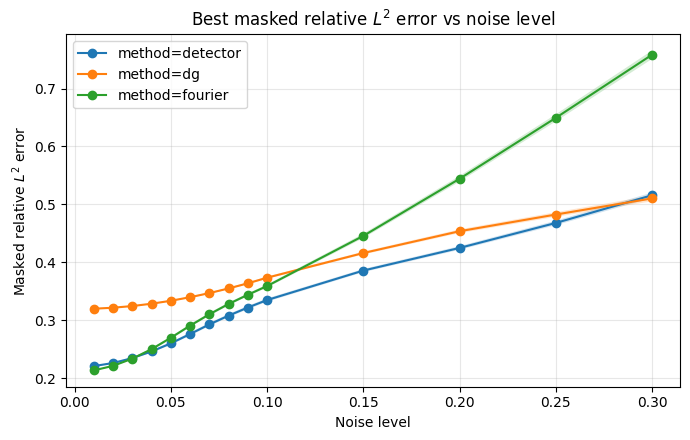

In [5]:
best_masked_rel_l2 = select_best_by_noise(
    summary_all,
    metric="masked_rel_l2_err",
    minimize=True,
)

display_best_params(best_masked_rel_l2, metric="masked_rel_l2_err")

plot_mc_metric(
    best_masked_rel_l2,
    metric="masked_rel_l2_err",
    title="Best masked relative $L^2$ error vs noise level",
    ylabel="Masked relative $L^2$ error",
    style_cols=[],
)

,method,noise_level,p,moments,BSorder,gw_ssim_mean,gw_ssim_std
0,detector,0.01,NaN,6,8,0.934504,0.000301
1,detector,0.02,NaN,6,8,0.930025,0.000595
2,detector,0.03,NaN,6,8,0.923063,0.000880
3,detector,0.04,NaN,6,8,0.914155,0.001158
4,detector,0.05,NaN,6,8,0.903794,0.001433
5,detector,0.06,NaN,6,8,0.892388,0.001706
6,detector,0.07,NaN,6,10,0.880819,0.001942
7,detector,0.08,NaN,6,12,0.869629,0.002176
8,detector,0.09,NaN,4,10,0.858884,0.002421
9,detector,0.10,NaN,4,12,0.848596,0.002628


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best gradient-weighted SSIM vs noise level'}, xlabel='Noise level', ylabel='Gradient-weighted SSIM'>)

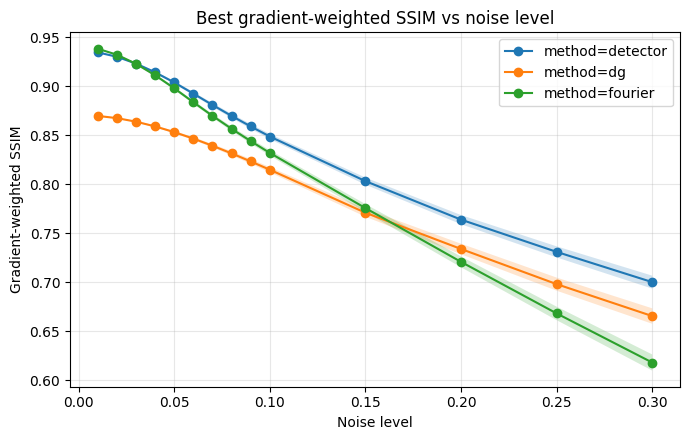

In [6]:
best_gw_ssim = select_best_by_noise(
    summary_all,
    metric="gw_ssim",
    minimize=False,
)

display_best_params(best_gw_ssim, metric="gw_ssim")

plot_mc_metric(
    best_gw_ssim,
    metric="gw_ssim",
    title="Best gradient-weighted SSIM vs noise level",
    ylabel="Gradient-weighted SSIM",
    style_cols=[],
)

,method,noise_level,p,moments,BSorder,ssim_mean,ssim_std
0,detector,0.01,NaN,2,20,0.771101,0.000884
1,detector,0.02,NaN,2,20,0.748573,0.001738
2,detector,0.03,NaN,2,20,0.715588,0.002485
3,detector,0.04,NaN,2,20,0.676806,0.003054
4,detector,0.05,NaN,2,20,0.636286,0.003412
5,detector,0.06,NaN,2,20,0.596860,0.003576
6,detector,0.07,NaN,2,20,0.560145,0.003592
7,detector,0.08,NaN,2,20,0.526848,0.003511
8,detector,0.09,NaN,2,20,0.497097,0.003376
9,detector,0.10,NaN,2,20,0.470706,0.003217


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best SSIM vs noise level'}, xlabel='Noise level', ylabel='SSIM'>)

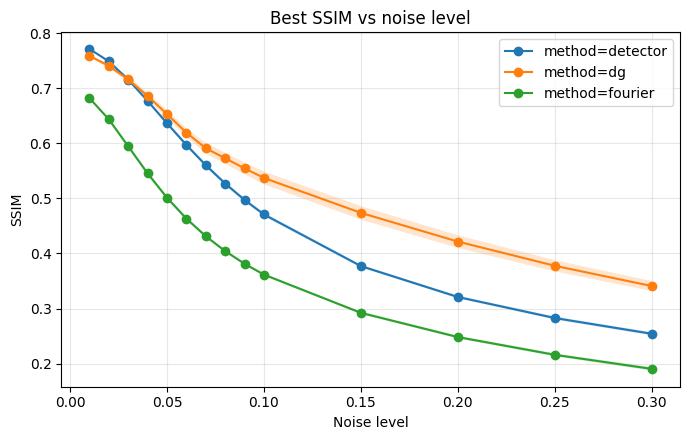

In [7]:
best_ssim = select_best_by_noise(
    summary_all,
    metric="ssim",
    minimize=False,
)

display_best_params(best_ssim, metric="ssim")

plot_mc_metric(
    best_ssim,
    metric="ssim",
    title="Best SSIM vs noise level",
    ylabel="SSIM",
    style_cols=[],
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Selected DG degree vs noise level'}, xlabel='Noise level', ylabel='DG degree'>)

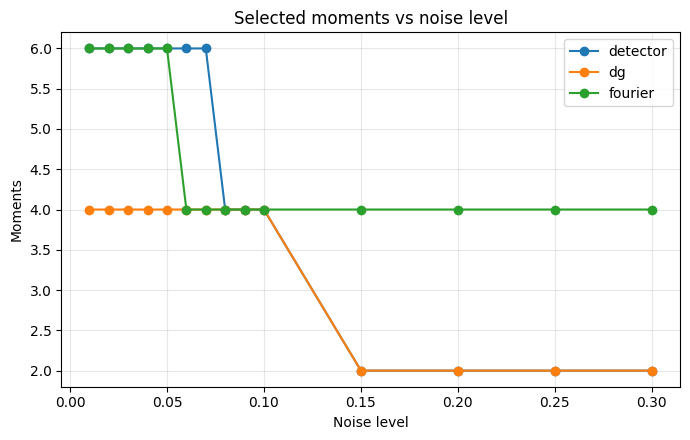

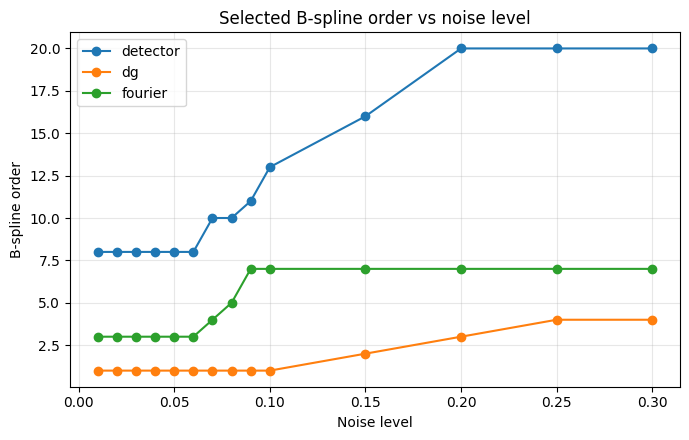

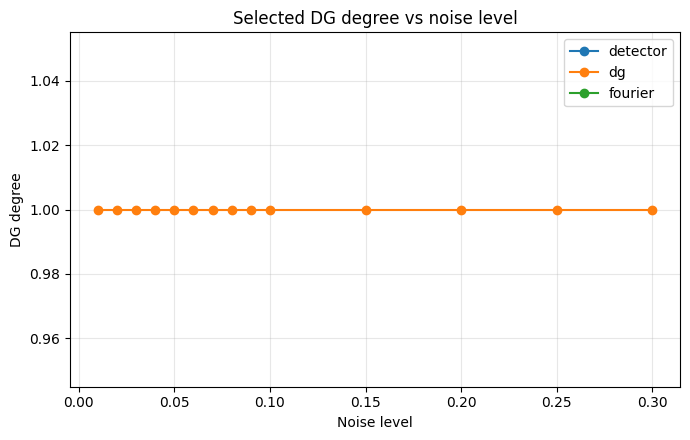

In [8]:
plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="moments",
    title="Selected moments vs noise level",
    ylabel="Moments",
)

plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="BSorder",
    title="Selected B-spline order vs noise level",
    ylabel="B-spline order",
)

plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="p",
    title="Selected DG degree vs noise level",
    ylabel="DG degree",
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'DG (p=1): masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

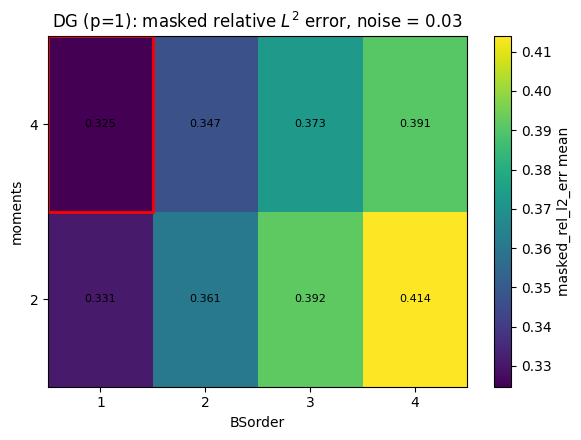

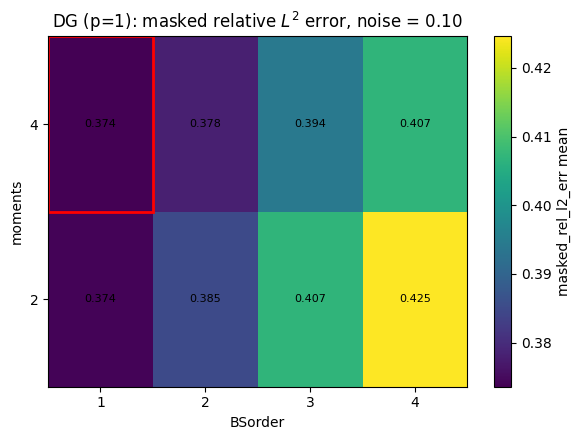

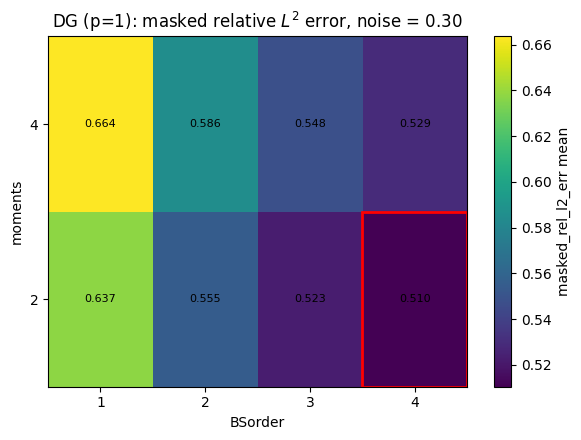

In [9]:
plot_param_heatmap(
    summary_all,
    method="dg",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.03",
)
plot_param_heatmap(
    summary_all,
    method="dg",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.10",
)
plot_param_heatmap(
    summary_all,
    method="dg",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.30",
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'DG (p=3): masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

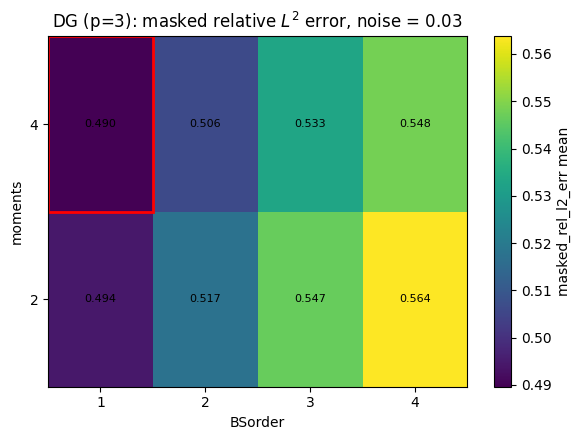

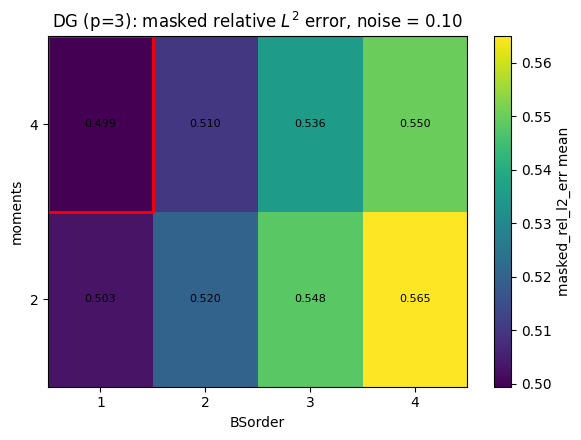

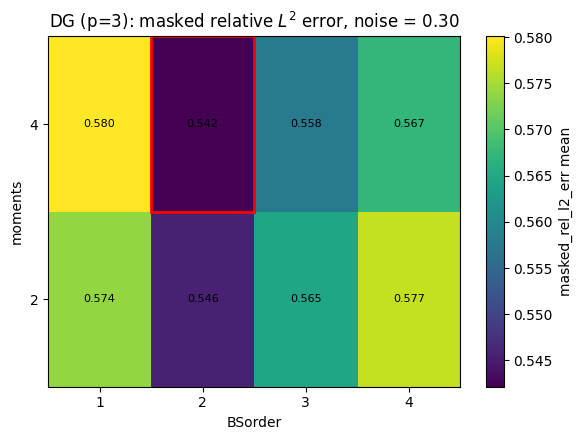

In [10]:
plot_param_heatmap(
    summary_all,
    method="dg",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    fixed_filters={"p": 3},
    title="DG (p=3): masked relative $L^2$ error, noise = 0.03",
)

plot_param_heatmap(
    summary_all,
    method="dg",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    fixed_filters={"p": 3},
    title="DG (p=3): masked relative $L^2$ error, noise = 0.10",
)

plot_param_heatmap(
    summary_all,
    method="dg",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    fixed_filters={"p": 3},
    title="DG (p=3): masked relative $L^2$ error, noise = 0.30",
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'Fourier: masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

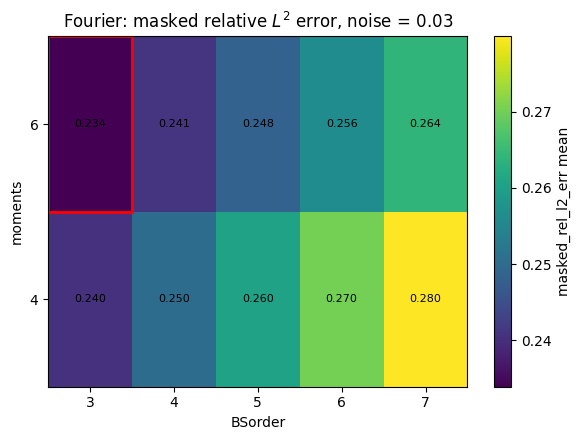

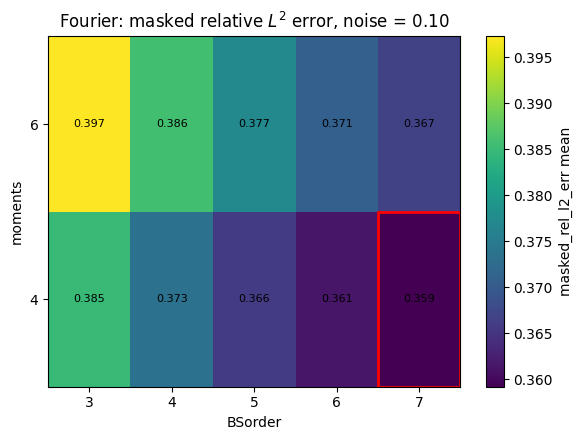

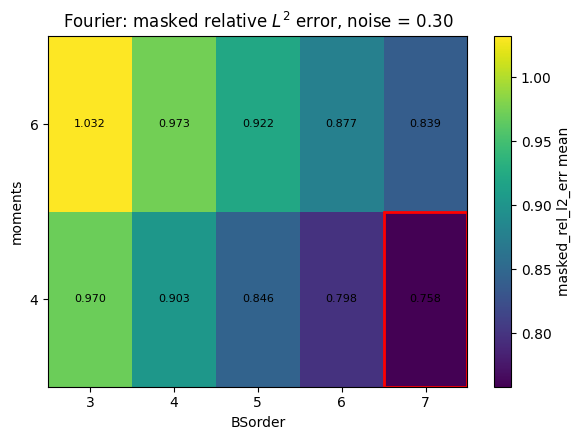

In [11]:
plot_param_heatmap(
    summary_all,
    method="fourier",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    title="Fourier: masked relative $L^2$ error, noise = 0.03",
)
plot_param_heatmap(
    summary_all,
    method="fourier",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    title="Fourier: masked relative $L^2$ error, noise = 0.10",
)
plot_param_heatmap(
    summary_all,
    method="fourier",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    title="Fourier: masked relative $L^2$ error, noise = 0.30",
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'Detector: masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

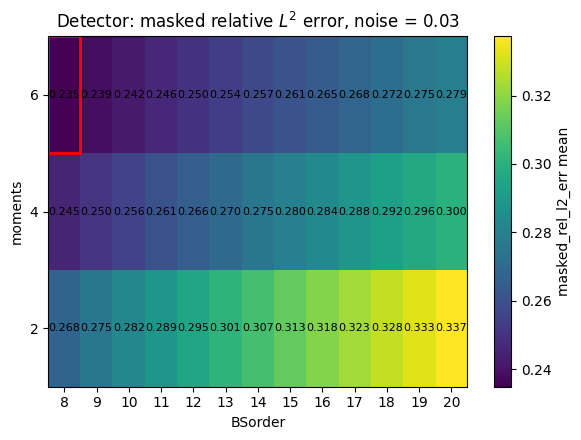

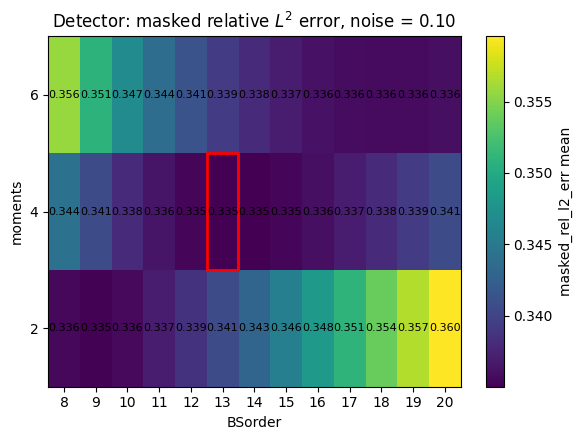

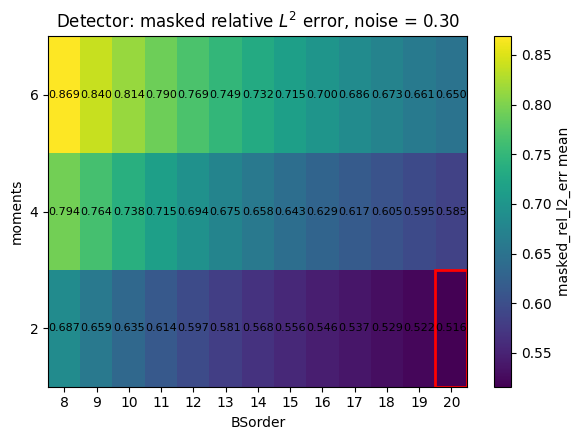

In [12]:
plot_param_heatmap(
    summary_all,
    method="detector",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    title="Detector: masked relative $L^2$ error, noise = 0.03",
)
plot_param_heatmap(
    summary_all,
    method="detector",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    title="Detector: masked relative $L^2$ error, noise = 0.10",
)
plot_param_heatmap(
    summary_all,
    method="detector",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    title="Detector: masked relative $L^2$ error, noise = 0.30",
)

In [13]:
fixed_params_10_masked = select_fixed_params_from_reference_noise(
    summary_all,
    metric="masked_rel_l2_err",
    reference_noise=0.10,
    minimize=True,
)

fixed_params_10_masked[
    ["method", "p", "moments", "BSorder", "masked_rel_l2_err_mean", "masked_rel_l2_err_std"]
].sort_values("method").reset_index(drop=True)

fixed_curves_10_masked = filter_summary_by_fixed_params(
    summary_all,
    fixed_params_10_masked,
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Fixed parameters chosen at 10% noise: masked relative $L^2$ vs noise level'}, xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

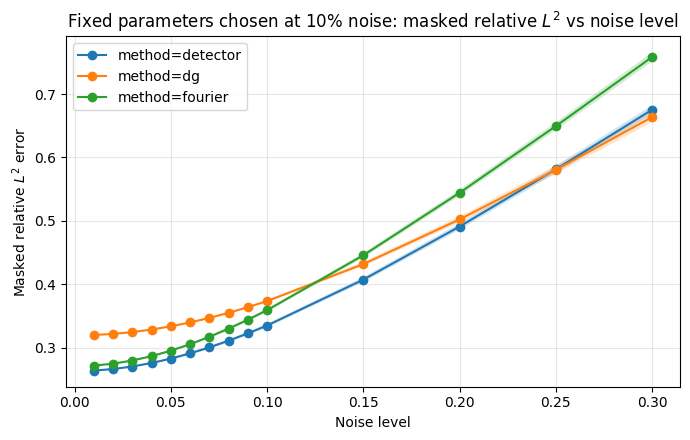

In [14]:
plot_mc_metric(
    fixed_curves_10_masked,
    metric="masked_rel_l2_err",
    title="Fixed parameters chosen at 10% noise: masked relative $L^2$ vs noise level",
    ylabel="Masked relative $L^2$ error",
    style_cols=[],
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Fixed parameters chosen at 10% noise: SSIM vs noise level'}, xlabel='Noise level', ylabel='SSIM'>)

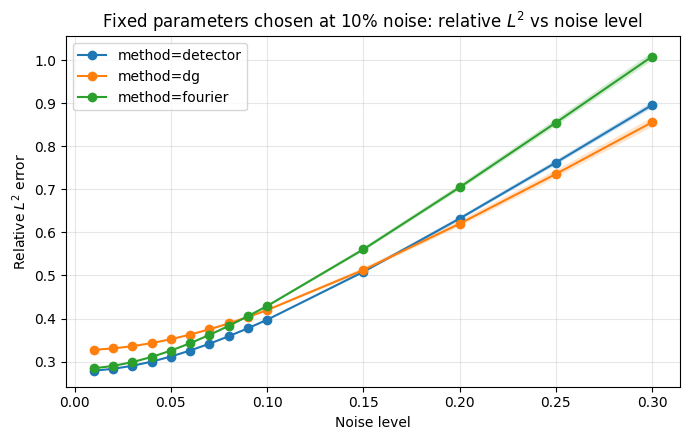

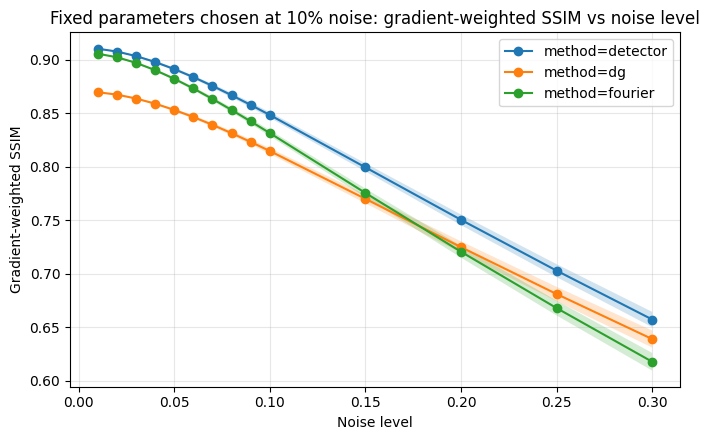

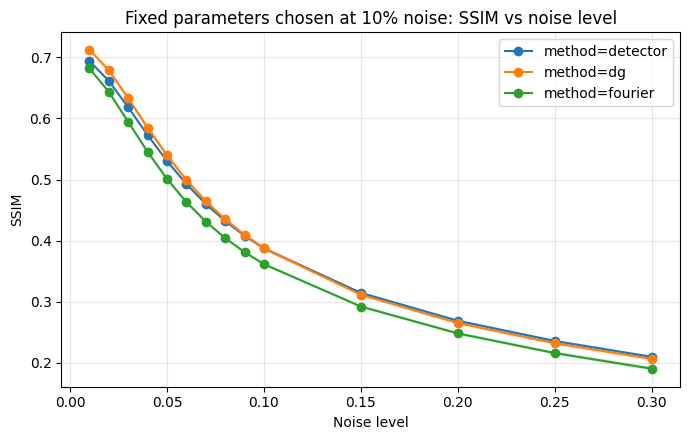

In [15]:
plot_mc_metric(
    fixed_curves_10_masked,
    metric="rel_l2_err",
    title="Fixed parameters chosen at 10% noise: relative $L^2$ vs noise level",
    ylabel="Relative $L^2$ error",
    style_cols=[],
)

plot_mc_metric(
    fixed_curves_10_masked,
    metric="gw_ssim",
    title="Fixed parameters chosen at 10% noise: gradient-weighted SSIM vs noise level",
    ylabel="Gradient-weighted SSIM",
    style_cols=[],
)

plot_mc_metric(
    fixed_curves_10_masked,
    metric="ssim",
    title="Fixed parameters chosen at 10% noise: SSIM vs noise level",
    ylabel="SSIM",
    style_cols=[],
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Retuned vs fixed parameters (chosen at 10% noise)'}, xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

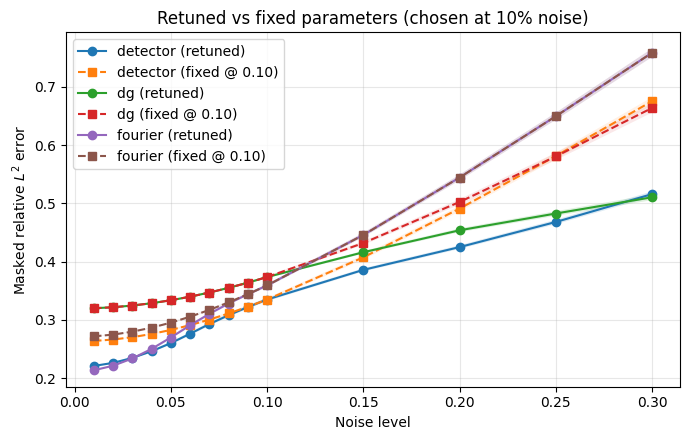

In [16]:
compare_fixed_vs_retuned(
    retuned_df=best_masked_rel_l2,
    fixed_df=fixed_curves_10_masked,
    metric="masked_rel_l2_err",
    title="Retuned vs fixed parameters (chosen at 10% noise)",
    ylabel="Masked relative $L^2$ error",
)